# Credit Score Predictor — Model Training & Evaluation

---

**Dataset:** `comprehensive_loan_data.csv`  
**Target Variable:** `Repayment_Status` — Binary classification (0 = Default / Not Approved, 1 = Repaid / Approved)

---

## Models Trained

| # | Model | Type | Why Selected |
|---|-------|------|--------------------|
| 1 | **Logistic Regression** | Linear Classifier | Interpretable probabilistic baseline; strong when decision boundary is approximately linear |
| 2 | **Random Forest Classifier** | Ensemble Tree Method | Captures non-linear interactions; robust to outliers; natively provides feature importance |
| 3 | **TensorFlow / Keras Deep MLP** | Deep Neural Network | Learns complex non-linear feature interactions; trained end-to-end via gradient descent with early stopping |

## Explainable AI (XAI) Techniques Applied

| Technique | Scope | Libraries |
|-----------|-------|-----------|
| SHAP (SHapley Additive exPlanations) | Global + Local | `shap` |
| Permutation Feature Importance | Global, model-agnostic | `sklearn.inspection` |
| Gini / Coefficient Importance | Global, model-specific | Built-in |
| Confusion Matrix + ROC-AUC | Performance audit | `sklearn.metrics` |
| Cross-Validation Score Distribution | Stability audit | `sklearn.model_selection` |

---

## Section 1 · Environment Setup

We import every library required for this notebook. Key dependency groups:

- **Data wrangling:** `pandas`, `numpy`
- **Visualization:** `matplotlib`, `seaborn`
- **Machine Learning:** `scikit-learn` (preprocessing, models, evaluation, inspection)
- **Explainable AI:** `shap` (install via `pip install shap` if needed)

In [33]:
# ── Core data libraries ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation libraries ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: preprocessing ────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler

# ── Scikit-learn: models ───────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: evaluation ───────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve
)

# ── Scikit-learn: model inspection ────────────────────────────────────────────
from sklearn.inspection import permutation_importance

# ── Explainable AI ─────────────────────────────────────────────────────────────
import shap

# ── Utility ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
sns.set_style('whitegrid')
RANDOM_STATE = 42

print('All libraries loaded successfully ✓')
print(f'scikit-learn: {__import__("sklearn").__version__}')
print(f'shap        : {shap.__version__}')

All libraries loaded successfully ✓
scikit-learn: 1.8.0
shap        : 0.51.0


---
## Section 2 · Data Loading & Overview

### Dataset Schema

| Column | Role | Type | Description |
|--------|------|------|-------------|
| `Age` | Feature | Numeric | Applicant age in years (18–74) |
| `Monthly_Income` | Feature | Numeric | Gross monthly income in USD |
| `Credit_Score` | Feature | Numeric | FICO-style score (300–849) |
| `Loan_Amount_Requested` | Feature | Numeric | Requested loan value in USD |
| `Employment_Status` | Feature | Categorical | Employed / Self-Employed / Unemployed / Student |
| `Existing_Debts` | Feature | Numeric | Total current debt obligations in USD |
| `Number_of_Previous_Loans` | Feature | Numeric | Count of prior loan applications |
| `Payment_History` | Feature | Ordinal | Poor → Fair → Good → Excellent |
| `Debt_to_Income_Ratio` | Feature | Numeric | Monthly debt / monthly income (0–1) |
| **`Repayment_Status`** | **Target** | **Binary** | **0 = Default / Rejected, 1 = Repaid / Approved** |

In [34]:
# Load dataset
df = pd.read_csv('comprehensive_loan_data.csv')

print(f'Dataset shape : {df.shape[0]} rows × {df.shape[1]} columns')
print('\n── Column types ──────────────────────────────────────────────')
print(df.dtypes)
print('\n── Missing values ────────────────────────────────────────────')
print(df.isnull().sum())
print('\n── Target class distribution ─────────────────────────────────')
counts = df['Repayment_Status'].value_counts()
for label, count in counts.items():
    tag = 'Default (0)' if label == 0 else 'Repaid  (1)'
    print(f'  {tag} : {count:3d}  ({count/len(df)*100:.1f}%)')
df.describe().round(2)

Dataset shape : 10000 rows × 10 columns

── Column types ──────────────────────────────────────────────
Age                           int64
Monthly_Income                int64
Credit_Score                  int64
Loan_Amount_Requested         int64
Employment_Status               str
Existing_Debts                int64
Number_of_Previous_Loans      int64
Payment_History                 str
Debt_to_Income_Ratio        float64
Repayment_Status              int64
dtype: object

── Missing values ────────────────────────────────────────────
Age                         0
Monthly_Income              0
Credit_Score                0
Loan_Amount_Requested       0
Employment_Status           0
Existing_Debts              0
Number_of_Previous_Loans    0
Payment_History             0
Debt_to_Income_Ratio        0
Repayment_Status            0
dtype: int64

── Target class distribution ─────────────────────────────────
  Repaid  (1) : 6980  (69.8%)
  Default (0) : 3020  (30.2%)


,Age,Monthly_Income,Credit_Score,Loan_Amount_Requested,Existing_Debts,Number_of_Previous_Loans,Debt_to_Income_Ratio,Repayment_Status
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,46.17,10818.45,576.04,25289.37,7450.06,4.46,0.38,0.70
std,16.42,5377.38,159.15,14142.69,4343.79,2.87,0.19,0.46
min,18.00,1502.00,300.00,1001.00,2.00,0.00,0.05,0.00
25%,32.00,6167.50,437.00,13096.75,3699.50,2.00,0.21,0.00
50%,46.00,10862.00,576.50,25138.50,7450.50,4.00,0.38,1.00
75%,61.00,15465.50,713.00,37542.25,11203.00,7.00,0.54,1.00
max,74.00,19997.00,849.00,49995.00,14998.00,9.00,0.70,1.00


---
## Section 3 · Feature Engineering & Preprocessing

### Steps Applied

1. **Ordinal Encoding — `Payment_History`**  
   `Payment_History` has a natural order (Poor < Fair < Good < Excellent). We map it to integers `{0, 1, 2, 3}` to preserve the ordinality.  
   Mapping: `Poor→0`, `Fair→1`, `Good→2`, `Excellent→3`

2. **One-Hot Encoding — `Employment_Status`**  
   `Employment_Status` is a nominal (unordered) categorical variable. We use one-hot encoding to prevent the model from inferring a spurious ordinal relationship.  
   `drop_first=True` removes one reference category to avoid multicollinearity (the "dummy variable trap").

3. **Train / Test Split (80 / 20) with Stratification**  
   `stratify=y` ensures both splits preserve the class ratio from the full dataset, preventing a skewed evaluation.

4. **Feature Scaling — `StandardScaler`**  
   Logistic Regression is sensitive to feature scale because the regularisation penalty (`C`) applies uniformly across all coefficients. We standardise features to zero mean, unit variance.  
   ⚠ The scaler is **fit only on training data** and then applied to the test set — this prevents data leakage.

   > Random Forest is **scale-invariant** (splits are based on relative rank, not absolute distance), so it uses the un-scaled feature matrix.

In [35]:
df_ml = df.copy()

# ── 1. Ordinal encoding: Payment_History ──────────────────────────────────────
payment_order = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
df_ml['Payment_History'] = df_ml['Payment_History'].map(payment_order)

# ── 2. One-hot encoding: Employment_Status ────────────────────────────────────
df_ml = pd.get_dummies(df_ml, columns=['Employment_Status'], drop_first=True)

# ── 3. Feature / target split ─────────────────────────────────────────────────
TARGET   = 'Repayment_Status'
FEATURES = [c for c in df_ml.columns if c != TARGET]

X = df_ml[FEATURES]
y = df_ml[TARGET]

print(f'Number of features : {len(FEATURES)}')
print(f'Feature names      : {FEATURES}')

# ── 4. Stratified train/test split (80/20) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# ── 5. Feature scaling (fit on train, transform both) ─────────────────────────
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

# Keep as DataFrames so SHAP can use feature names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURES)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=FEATURES)

print(f'\nTraining samples : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test samples     : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'Class ratio (train) — 0: {(y_train==0).sum()}  | 1: {(y_train==1).sum()}')
print(f'Class ratio (test)  — 0: {(y_test==0).sum()}   | 1: {(y_test==1).sum()}')

Number of features : 11
Feature names      : ['Age', 'Monthly_Income', 'Credit_Score', 'Loan_Amount_Requested', 'Existing_Debts', 'Number_of_Previous_Loans', 'Payment_History', 'Debt_to_Income_Ratio', 'Employment_Status_Self-Employed', 'Employment_Status_Student', 'Employment_Status_Unemployed']

Training samples : 8000 (80%)
Test samples     : 2000  (20%)
Class ratio (train) — 0: 2416  | 1: 5584
Class ratio (test)  — 0: 604   | 1: 1396


---
## Section 4 · Model 1 — Logistic Regression

### 4.1 Architecture

Logistic Regression is a **discriminative linear classifier** that models the log-odds of the positive class as a linear combination of input features:

$$\log\left(\frac{P(y=1|\mathbf{x})}{P(y=0|\mathbf{x})}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

Rearranging, the predicted probability is given by the **sigmoid (logistic) function**:

$$P(y=1|\mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

The output is a probability in $(0, 1)$. A threshold (default 0.5) converts this to a class label.

### 4.2 How the Model Learns — Optimisation

The model minimises **Binary Cross-Entropy loss** (negative log-likelihood):

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log\hat{p}_i + (1-y_i)\log(1-\hat{p}_i)\right]$$

With **L2 regularisation** (Ridge), the full objective becomes:

$$\mathcal{L}_{\text{reg}}(\mathbf{w}) = \mathcal{L}(\mathbf{w}) + \frac{\lambda}{2}\|\mathbf{w}\|_2^2 \quad \text{where} \quad \lambda = \frac{1}{C}$$

With **L1 regularisation** (Lasso), the penalty promotes coefficient sparsity (feature selection):

$$\mathcal{L}_{\text{reg}}(\mathbf{w}) = \mathcal{L}(\mathbf{w}) + \lambda\|\mathbf{w}\|_1$$

The `liblinear` solver uses **coordinate descent** to find the minimum analytically/iteratively.

### 4.3 Parameters & Hyperparameters Tuned

| Hyperparameter | Role | Search Values | Notes |
|----------------|------|---------------|-------|
| `C` | Controls regularisation strength (`C = 1/λ`). High C → less regularisation → risk of overfitting | `[0.001, 0.01, 0.1, 1, 10, 100]` | Most important LR hyperparameter |
| `penalty` | Type of regularisation applied to coefficients | `['l1', 'l2']` | L1 induces sparsity; L2 shrinks all |
| `solver` | Numerical optimisation algorithm | `['liblinear']` | Only solver supporting both L1 & L2 |
| `max_iter` | Maximum iterations for solver convergence | `[1000]` | Fixed high to ensure convergence |

**Search strategy:** `GridSearchCV` with 5-fold stratified cross-validation, scored by **ROC-AUC** (preferred over accuracy for class-imbalanced evaluation).

In [36]:
# ── Cross-validation strategy ─────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Hyperparameter search space ───────────────────────────────────────────────
lr_param_grid = {
    'C':        [0.001, 0.01, 0.1, 1, 10, 100],  # inverse regularisation
    'penalty':  ['l1', 'l2'],                      # regularisation type
    'solver':   ['liblinear'],                     # supports both L1 & L2
    'max_iter': [1000],                            # ensure convergence
}

# ── Grid search (ROC-AUC as scoring metric) ───────────────────────────────────
lr_grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    lr_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    refit=True
)
lr_grid.fit(X_train_scaled, y_train)

lr_best = lr_grid.best_estimator_

print('══ Logistic Regression — Hyperparameter Tuning Results ══')
print(f'Best hyperparameters : {lr_grid.best_params_}')
print(f'Best CV ROC-AUC      : {lr_grid.best_score_:.4f}')
print(f'\nTop 5 parameter combinations by mean test ROC-AUC:')
cv_results = pd.DataFrame(lr_grid.cv_results_)
top5 = (cv_results[['params', 'mean_test_score', 'std_test_score']]
        .sort_values('mean_test_score', ascending=False)
        .head())
print(top5.to_string(index=False))

══ Logistic Regression — Hyperparameter Tuning Results ══
Best hyperparameters : {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC-AUC      : 0.9583

Top 5 parameter combinations by mean test ROC-AUC:
                                                              params  mean_test_score  std_test_score
{'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}         0.958271        0.005391
  {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}         0.958153        0.005424
{'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}         0.958130        0.005408
  {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}         0.958128        0.005420
{'C': 100, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}         0.958123        0.005415


### 4.4 Model Evaluation

We evaluate using:
- **Accuracy** — fraction of correct predictions (sensitive to class imbalance)
- **Precision / Recall / F1** — per-class metrics; F1 is the harmonic mean of Precision & Recall
- **ROC-AUC** — area under the Receiver Operating Characteristic curve; threshold-independent
- **Confusion Matrix** — raw breakdown of TP, TN, FP, FN

══ Logistic Regression — Test Set Performance ══
  Accuracy          : 0.9000
  ROC-AUC           : 0.9608
  Avg Precision     : 0.9830

              precision    recall  f1-score   support

 Default (0)       0.86      0.80      0.83       604
  Repaid (1)       0.92      0.94      0.93      1396

    accuracy                           0.90      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.90      0.90      0.90      2000



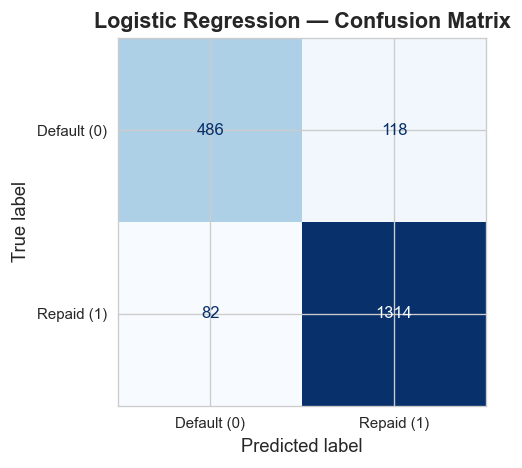

In [37]:
# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_lr = lr_best.predict(X_test_scaled)
y_prob_lr = lr_best.predict_proba(X_test_scaled)[:, 1]  # P(Repaid)

# ── Scalar metrics ────────────────────────────────────────────────────────────
acc_lr    = accuracy_score(y_test, y_pred_lr)
roc_lr    = roc_auc_score(y_test, y_prob_lr)
ap_lr     = average_precision_score(y_test, y_prob_lr)

print('══ Logistic Regression — Test Set Performance ══')
print(f'  Accuracy          : {acc_lr:.4f}')
print(f'  ROC-AUC           : {roc_lr:.4f}')
print(f'  Avg Precision     : {ap_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr,
                             target_names=['Default (0)', 'Repaid (1)']))

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Default (0)', 'Repaid (1)'],
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 XAI — Logistic Regression Coefficient Analysis

Since Logistic Regression produces a linear model, **the learned coefficients are the model's explanation**. After scaling:

- A **positive** $\beta_j$ means feature $x_j$ increases the log-odds of repayment (positive signal).
- A **negative** $\beta_j$ means feature $x_j$ decreases the log-odds of repayment (risk signal).
- The **magnitude** $|\beta_j|$ reflects relative importance (all features are scaled).

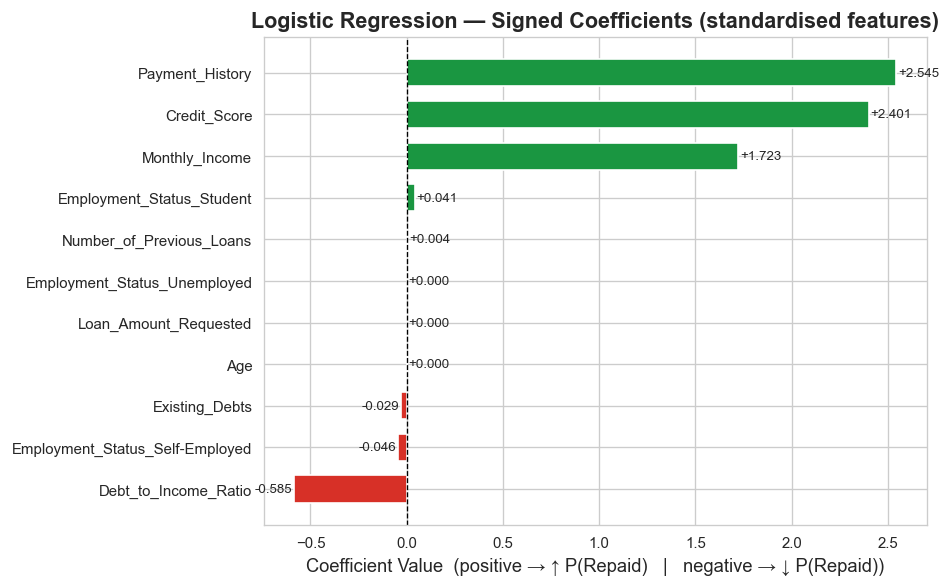


Top 3 positive drivers (increase repayment probability):
Payment_History    2.545158
Credit_Score       2.401103
Monthly_Income     1.722513

Top 3 negative drivers (increase default probability):
Debt_to_Income_Ratio              -0.584865
Employment_Status_Self-Employed   -0.045841
Existing_Debts                    -0.029235


In [38]:
# ── Coefficient plot (signed) ─────────────────────────────────────────────────
coef_series = pd.Series(lr_best.coef_[0], index=FEATURES).sort_values()

colours = ['#d73027' if c < 0 else '#1a9641' for c in coef_series]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(coef_series.index, coef_series.values,
               color=colours, edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression — Signed Coefficients (standardised features)',
             fontweight='bold')
ax.set_xlabel('Coefficient Value  (positive → ↑ P(Repaid)   |   negative → ↓ P(Repaid))')
# annotate values
for bar, val in zip(bars, coef_series.values):
    xpos = val + 0.01 if val >= 0 else val - 0.01
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=8)
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTop 3 positive drivers (increase repayment probability):')
print(coef_series.nlargest(3).to_string())
print('\nTop 3 negative drivers (increase default probability):')
print(coef_series.nsmallest(3).to_string())

---
## Section 5 · Model 2 — Random Forest Classifier

### 5.1 Architecture

A **Random Forest** is a **bootstrap-aggregated (bagged) ensemble** of $T$ decision trees. Each tree $h_t(\mathbf{x})$ is trained on a bootstrap sample of the training data (sampling with replacement) and at each split considers only a **random subset** of `max_features` features.  
The final prediction aggregates all trees by **majority vote**:

$$\hat{y} = \text{mode}\{h_1(\mathbf{x}), h_2(\mathbf{x}), \ldots, h_T(\mathbf{x})\}$$

Predicted probability (used for ROC-AUC) is the fraction of trees voting for the positive class:

$$\hat{P}(y=1|\mathbf{x}) = \frac{1}{T}\sum_{t=1}^{T} \mathbf{1}[h_t(\mathbf{x}) = 1]$$

### 5.2 How Individual Trees Learn

Each CART (Classification And Regression Tree) node selects the best split $(j^*, \theta^*)$ by maximising the **Gini impurity reduction**:

$$\Delta\text{Gini} = \text{Gini}(D) - \frac{|D_L|}{|D|}\text{Gini}(D_L) - \frac{|D_R|}{|D|}\text{Gini}(D_R)$$

where $\text{Gini}(D) = 1 - \sum_k p_k^2$ and $p_k$ is the fraction of class $k$ in node $D$.

### 5.3 Why Random Forest Reduces Variance (Bias-Variance Tradeoff)

- A single deep tree has **low bias but high variance** (overfits). 
- Averaging $T$ uncorrelated trees keeps bias constant but reduces variance by factor $1/T$.
- **Feature sub-sampling** at each split decorrelates the trees, making the variance reduction more effective.

### 5.4 Parameters & Hyperparameters Tuned

| Hyperparameter | Role | Search Values |
|----------------|------|---------------|
| `n_estimators` | Number of trees $T$; more trees → lower variance, diminishing returns | `[100, 200, 300]` |
| `max_depth` | Maximum depth of each tree; deeper → more expressive, may overfit | `[None, 5, 10, 20]` |
| `min_samples_split` | Minimum samples needed to split a node; higher → simpler tree | `[2, 5, 10]` |
| `min_samples_leaf` | Minimum samples at a leaf; acts as regulariser | `[1, 2, 4]` |
| `max_features` | Features considered at each split; `sqrt` is standard for classification | `['sqrt', 'log2']` |

In [ ]:
# ── Hyperparameter search space ───────────────────────────────────────────────
rf_param_grid = {
    'n_estimators':     [100, 200, 300],      # number of trees
    'max_depth':        [None, 5, 10, 20],    # tree depth
    'min_samples_split':[2, 5, 10],           # node split threshold
    'min_samples_leaf': [1, 2, 4],            # leaf size threshold
    'max_features':     ['sqrt', 'log2'],      # feature sub-sampling
}

# ── Grid search (ROC-AUC as scoring metric) ───────────────────────────────────
rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced',   # compensate for any class imbalance
        n_jobs=-1
    ),
    rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=1,   # outer loop uses 1 job; inner RF uses n_jobs=-1
    verbose=0,
    refit=True
)
# RF does NOT require feature scaling
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_

print('══ Random Forest — Hyperparameter Tuning Results ══')
print(f'Best hyperparameters : {rf_grid.best_params_}')
print(f'Best CV ROC-AUC      : {rf_grid.best_score_:.4f}')
print(f'\nTop 5 parameter combinations by mean test ROC-AUC:')
rf_cv_results = pd.DataFrame(rf_grid.cv_results_)
top5_rf = (rf_cv_results[['params', 'mean_test_score', 'std_test_score']]
           .sort_values('mean_test_score', ascending=False)
           .head())
print(top5_rf.to_string(index=False))

### 5.5 Model Evaluation

In [ ]:
# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]  # P(Repaid)

acc_rf    = accuracy_score(y_test, y_pred_rf)
roc_rf    = roc_auc_score(y_test, y_prob_rf)
ap_rf     = average_precision_score(y_test, y_prob_rf)

print('══ Random Forest — Test Set Performance ══')
print(f'  Accuracy          : {acc_rf:.4f}')
print(f'  ROC-AUC           : {roc_rf:.4f}')
print(f'  Avg Precision     : {ap_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf,
                             target_names=['Default (0)', 'Repaid (1)']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Default (0)', 'Repaid (1)'],
    cmap='Greens', colorbar=False, ax=ax
)
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 XAI — Gini Feature Importance (Built-in)

The **Mean Decrease in Impurity (MDI)** measures how much each feature reduces the weighted Gini impurity across all trees and splits:

$$\text{Importance}(x_j) = \frac{1}{T}\sum_{t=1}^{T}\sum_{v \in \text{nodes}(t) \text{ splitting on } j} \frac{|D_v|}{|D|}\,\Delta\text{Gini}(v)$$

⚠ MDI can be biased toward high-cardinality numerical features. We complement it with permutation importance below.

In [ ]:
fi_series = pd.Series(
    rf_best.feature_importances_,
    index=FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colours_fi = sns.color_palette('YlOrRd', len(fi_series))
ax.barh(fi_series.index, fi_series.values,
        color=colours_fi, edgecolor='white', height=0.65)
ax.set_title('Random Forest — Gini Feature Importance (MDI)', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity (higher = more important)')
for i, val in enumerate(fi_series.values):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('rf_gini_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 · Explainable AI (XAI) — Deep Dive

### 6.1 Permutation Feature Importance (Model-Agnostic)

**How it works:** For each feature $x_j$, its values in the test set are randomly shuffled (breaking the feature-target association). The **drop in ROC-AUC** is recorded. A larger drop means the feature was more important.

$$\text{PI}(x_j) = s_{\text{original}} - \frac{1}{K}\sum_{k=1}^{K} s_{k,\text{shuffled}(j)}$$

We repeat the shuffle 30 times ($K=30$) to estimate variation (shown as error bars). This is **model-agnostic** and avoids the MDI bias toward high-cardinality features.

In [ ]:
# ── Permutation importance on test set (ROC-AUC) ──────────────────────────────
perm_result = permutation_importance(
    rf_best, X_test, y_test,
    n_repeats=30, random_state=RANDOM_STATE,
    scoring='roc_auc', n_jobs=-1
)

perm_df = (
    pd.DataFrame({
        'feature':         FEATURES,
        'importance_mean': perm_result.importances_mean,
        'importance_std':  perm_result.importances_std,
    })
    .sort_values('importance_mean')
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    perm_df['feature'], perm_df['importance_mean'],
    xerr=perm_df['importance_std'],
    color='darkorange', edgecolor='white', capsize=4, height=0.65
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Random Forest — Permutation Feature Importance (± std over 30 shuffles)',
             fontweight='bold')
ax.set_xlabel('Mean Decrease in ROC-AUC when feature is permuted')
plt.tight_layout()
plt.savefig('rf_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeatures by permutation importance (descending):')
print(perm_df.sort_values('importance_mean', ascending=False)
      [['feature','importance_mean','importance_std']]
      .to_string(index=False))

### 6.2 SHAP — SHapley Additive exPlanations

SHAP assigns each feature $j$ a **Shapley value** $\phi_j$ for each prediction, rooted in coalitional game theory. The value represents the **average marginal contribution** of that feature across all possible feature orderings:

$$\phi_j(f, \mathbf{x}) = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!} \left[f_S(\mathbf{x}_S \cup \{x_j\}) - f_S(\mathbf{x}_S)\right]$$

**Key properties:**
- **Efficiency:** $f(\mathbf{x}) = \phi_0 + \sum_j \phi_j$  (SHAP values sum to the prediction - baseline)
- **Symmetry:** equal contribution features receive equal SHAP values
- **Dummy:** features that never affect the model get $\phi_j = 0$

**Explainer types used:**
- `shap.LinearExplainer` — exact SHAP for Logistic Regression (uses feature correlations)
- `shap.TreeExplainer` — exact SHAP for tree models, $O(TLD^2)$ complexity where $L$ = leaves, $D$ = depth

In [ ]:
# ── SHAP for Logistic Regression ──────────────────────────────────────────────
explainer_lr = shap.LinearExplainer(
    lr_best,
    X_train_scaled_df,
    feature_perturbation='interventional'
)
shap_values_lr = explainer_lr.shap_values(X_test_scaled_df)

# ── Global summary bar: mean |SHAP| ───────────────────────────────────────────
print('══ SHAP Global Importance — Logistic Regression ══')
shap.summary_plot(
    shap_values_lr, X_test_scaled_df,
    plot_type='bar', show=False
)
plt.title('Logistic Regression — Mean |SHAP| Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_lr_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SHAP Beeswarm: direction of impact ────────────────────────────────────────
# Each dot = one test sample; X-axis = SHAP value (impact on log-odds);
# colour = feature value (red = high, blue = low)
shap.summary_plot(
    shap_values_lr, X_test_scaled_df, show=False
)
plt.title('LR — SHAP Beeswarm: Direction & Magnitude of Feature Impact', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_lr_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SHAP for Random Forest (TreeExplainer — exact) ───────────────────────────
explainer_rf = shap.TreeExplainer(rf_best)
shap_values_rf_raw = explainer_rf.shap_values(X_test)

# For binary RF, shap_values is a 2-element list [class0, class1]; take class 1
if isinstance(shap_values_rf_raw, list):
    sv_rf    = np.array(shap_values_rf_raw[1])
    base_rf  = explainer_rf.expected_value[1]
else:
    sv_rf    = np.array(shap_values_rf_raw)
    base_rf  = explainer_rf.expected_value

X_test_df = pd.DataFrame(X_test.values, columns=FEATURES)

# ── Global summary bar ────────────────────────────────────────────────────────
print('══ SHAP Global Importance — Random Forest ══')
shap.summary_plot(
    sv_rf, X_test_df,
    plot_type='bar', show=False
)
plt.title('Random Forest — Mean |SHAP| Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_rf_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Beeswarm for RF ───────────────────────────────────────────────────────────
shap.summary_plot(
    sv_rf, X_test_df, show=False
)
plt.title('RF — SHAP Beeswarm: Direction & Magnitude of Feature Impact', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_rf_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SHAP Waterfall — local explanation for one test sample ────────────────────
# Pick first test sample; waterfall shows step-by-step feature contributions
idx = 0
exp = shap.Explanation(
    values       = sv_rf[idx],
    base_values  = base_rf,
    data         = X_test_df.iloc[idx].values,
    feature_names= FEATURES
)

shap.waterfall_plot(exp, max_display=12, show=False)
plt.title(
    f'RF — Local Explanation: Sample #{idx}  '
    f'(Predicted={y_pred_rf[idx]}, True={y_test.iloc[idx]})',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('shap_rf_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SHAP Force Plot — local explanation (notebook-rendered) ──────────────────
# Force plot shows base value + feature pushes toward/away from prediction
shap.initjs()
force_plot = shap.force_plot(
    base_rf,
    sv_rf[idx],
    X_test_df.iloc[idx],
    feature_names=FEATURES
)
force_plot

---
## Section 7 · Model Comparison

We compare both models across:
1. ROC curves (threshold-independent performance)
2. Precision-Recall curves (focus on positive class)
3. Cross-validation score distribution (stability)
4. Side-by-side summary table

In [ ]:
# ── ROC + Precision-Recall curves side-by-side ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_info = [
    ('Logistic Regression', y_prob_lr, 'steelblue'),
    ('Random Forest',       y_prob_rf, 'forestgreen'),
]

# ── ROC curves ────────────────────────────────────────────────────────────────
ax = axes[0]
for name, probs, colour in models_info:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=colour, lw=2, label=f'{name}  (AUC={auc:.3f})')
    ax.fill_between(fpr, tpr, alpha=0.07, color=colour)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC=0.500)')
ax.set(title='ROC Curves', xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.legend(loc='lower right', fontsize=9)

# ── Precision-Recall curves ───────────────────────────────────────────────────
ax = axes[1]
for name, probs, colour in models_info:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(recall, precision, color=colour, lw=2, label=f'{name}  (AP={ap:.3f})')
baseline = y_test.mean()
ax.axhline(baseline, color='gray', lw=1, linestyle='--',
           label=f'Baseline precision = {baseline:.2f}')
ax.set(title='Precision-Recall Curves',
       xlabel='Recall', ylabel='Precision', xlim=[0, 1], ylim=[0, 1])
ax.legend(loc='lower left', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cross-validation distribution (stability check) ──────────────────────────
cv_lr = cross_val_score(lr_best, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
cv_rf = cross_val_score(rf_best, X_train,        y_train, cv=cv, scoring='roc_auc')

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(
    [cv_lr, cv_rf],
    labels=['Logistic Regression', 'Random Forest'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')

for i, (scores, colour) in enumerate(zip([cv_lr, cv_rf], ['steelblue', 'forestgreen'])):
    x_jitter = np.random.normal(i + 1, 0.04, size=len(scores))
    ax.scatter(x_jitter, scores, color=colour, zorder=5, s=40, alpha=0.8)
    ax.text(i + 1, scores.max() + 0.005,
            f'μ={scores.mean():.3f}\nσ={scores.std():.3f}',
            ha='center', fontsize=9, color=colour)

ax.set_title('5-Fold Stratified Cross-Validation — ROC-AUC Distribution', fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.3, 1.05)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Summary comparison table ──────────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Best CV ROC-AUC':          [lr_grid.best_score_,           rf_grid.best_score_],
    'Test Accuracy':             [acc_lr,                        acc_rf],
    'Test ROC-AUC':              [roc_lr,                        roc_rf],
    'Test Avg Precision':        [ap_lr,                         ap_rf],
    'F1 (macro)':                [f1_score(y_test, y_pred_lr, average='macro'),
                                  f1_score(y_test, y_pred_rf, average='macro')],
    'CV ROC-AUC std':            [cv_lr.std(),                   cv_rf.std()],
    'Scale Invariant':           ['No (scaled)',                  'Yes'],
    'Interpretability':          ['High (coefficients)',          'Medium (SHAP/PI)'],
}).set_index('Model')

display(summary.T.round(4)
        .style.background_gradient(cmap='RdYlGn', axis=1,
                                   subset=pd.IndexSlice[
                                       ['Best CV ROC-AUC','Test Accuracy',
                                        'Test ROC-AUC','F1 (macro)'], :]))

In [ ]:
# ── Persist sklearn models + artifacts (runs inside this notebook) ────────────
import os, datetime, joblib
os.makedirs('models', exist_ok=True)
paths = {}

# Scaler and feature list
paths['scaler']   = 'models/scaler.joblib'
paths['features'] = 'models/features_list.joblib'
joblib.dump(scaler,   paths['scaler'])
joblib.dump(FEATURES, paths['features'])

# GridSearch objects and best estimators
paths['lr_grid'] = 'models/lr_grid.joblib'
paths['lr_best'] = 'models/logistic_regression_best.joblib'
paths['rf_grid'] = 'models/rf_grid.joblib'
paths['rf_best'] = 'models/random_forest_best.joblib'
joblib.dump(lr_grid, paths['lr_grid'])
joblib.dump(lr_best, paths['lr_best'])
joblib.dump(rf_grid, paths['rf_grid'])
joblib.dump(rf_best, paths['rf_best'])

# Metadata
metadata = {
    'saved_at_utc':   datetime.datetime.utcnow().isoformat() + 'Z',
    'random_state':   RANDOM_STATE,
    'lr_best_params': lr_grid.best_params_,
    'rf_best_params': rf_grid.best_params_,
}
joblib.dump(metadata, 'models/sklearn_models_metadata.joblib')

print('Saved sklearn artifacts:')
for k, v in paths.items():
    print(f'  {v}')
print('\nNote: TensorFlow / Keras model is saved in Section 8 below.')


---
## Section 8 · Model 3 — TensorFlow / Keras Deep MLP

### 8.1 Architecture

A **Multilayer Perceptron (MLP)** is a fully-connected feedforward neural network.
Each neuron computes:

$$a^{(l)} = \sigma\!\left(W^{(l)} a^{(l-1)} + b^{(l)}\right)$$

We use three hidden layers `[256 -> 128 -> 64]` with:
- **BatchNormalization** after each `Dense` layer -- accelerates training, reduces internal covariate shift
- **Dropout** (0.3 / 0.2 / 0.1) -- stochastic regularisation to prevent overfitting
- **ReLU** activations -- avoids vanishing gradients; computationally efficient
- **Sigmoid** output -- squashes final logit to $P(\text{Repaid}) \in (0,1)$

### 8.2 How the Model Learns

The network minimises **Binary Cross-Entropy** via **Adam** optimiser, which combines
momentum and RMSProp:

$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \varepsilon}\hat{m}_t$$

Training uses up to **1,000 epochs** with `EarlyStopping` (patience=30 on `val_loss`),
so training stops when validation performance plateaus. `restore_best_weights=True`
automatically keeps the best epoch.

### 8.3 Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Hidden units | 256 -> 128 -> 64 | Progressively compresses representation |
| Dropout rates | 0.3 / 0.2 / 0.1 | Tapering regularisation toward output |
| Optimiser | Adam, lr = 1e-3 | Fast, well-tuned default for tabular data |
| Batch size | 128 | Balance between gradient noise and speed |
| Max epochs | 1,000 | Hard upper bound; early stopping controls actual runtime |
| Early stopping patience | 30 | Allows temporary plateaus before halting |
| LR decay | x0.5 every 10 stagnant epochs | Helps escape shallow minima |
| `class_weight` | Balanced | Compensates for class imbalance |


In [ ]:
# ── TensorFlow / Keras availability check ─────────────────────────────────────
import os, random, joblib
import numpy as np
try:
    import tensorflow as tf
except ImportError:
    raise ImportError('TensorFlow not found. Install it with:  pip install tensorflow')

# ── Seeds for reproducibility ─────────────────────────────────────────────────
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow {tf.__version__}  |  GPUs available: {len(gpus)}')
if not gpus:
    print('Warning: No GPU detected. Training on CPU may take a few minutes.')

# ── Prepare float32 numpy arrays ──────────────────────────────────────────────
X_tr = np.array(X_train_scaled, dtype='float32')
X_te = np.array(X_test_scaled,  dtype='float32')
y_tr = np.array(y_train, dtype='float32')
y_te = np.array(y_test,  dtype='float32')
n_features = X_tr.shape[1]

# ── Class weights for imbalance ───────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weight_dict = {int(k): v for k, v in zip(np.unique(y_tr), cw)}
print(f'Class weights: {class_weight_dict}')

# ── Build MLP: Dense-BN-ReLU-Dropout x3 layers ───────────────────────────────
os.makedirs('models', exist_ok=True)
tf.keras.backend.clear_session()
init = tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)

tf_mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,), name='features'),
    tf.keras.layers.Dense(256, kernel_initializer=init),
    tf.keras.layers.BatchNormalization(), tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.3, seed=RANDOM_STATE),
    tf.keras.layers.Dense(128, kernel_initializer=init),
    tf.keras.layers.BatchNormalization(), tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.2, seed=RANDOM_STATE),
    tf.keras.layers.Dense(64, kernel_initializer=init),
    tf.keras.layers.BatchNormalization(), tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.1, seed=RANDOM_STATE),
    tf.keras.layers.Dense(1, activation='sigmoid', name='output'),
], name='credit_mlp')

tf_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
)
tf_mlp.summary()

# ── Callbacks: early stopping + best-weight checkpoint + LR decay ─────────────
ckpt_path = 'models/tf_mlp_best.weights.h5'
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=30, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ckpt_path, monitor='val_auc', mode='max',
        save_best_only=True, save_weights_only=True, verbose=0),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=0),
]

# ── Train (up to 1,000 epochs; EarlyStopping controls actual runtime) ─────────
history = tf_mlp.fit(
    X_tr, y_tr,
    epochs=1000,
    batch_size=128,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)

# ── Evaluate on held-out test set ─────────────────────────────────────────────
loss_tf, acc_tf, _ = tf_mlp.evaluate(X_te, y_te, verbose=0)
y_prob_tf = tf_mlp.predict(X_te, verbose=0).flatten()
y_pred_tf = (y_prob_tf >= 0.5).astype(int)
roc_tf    = roc_auc_score(y_te, y_prob_tf)
ap_tf     = average_precision_score(y_te, y_prob_tf)

print('\n== TF Keras Deep MLP -- Test Set Performance ==')
print(f'  Loss          : {loss_tf:.4f}')
print(f'  Accuracy      : {acc_tf:.4f}')
print(f'  ROC-AUC       : {roc_tf:.4f}')
print(f'  Avg Precision : {ap_tf:.4f}')
print(f'  Epochs run    : {len(history.history["loss"])}')
print()
print(classification_report(y_te.astype(int), y_pred_tf,
                             target_names=['Default (0)', 'Repaid (1)']))

# ── Training history plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set(title='Loss (binary cross-entropy)', xlabel='Epoch')
axes[0].legend()
axes[1].plot(history.history['auc'],     label='Train')
axes[1].plot(history.history['val_auc'], label='Val')
axes[1].set(title='ROC-AUC', xlabel='Epoch')
axes[1].legend()
plt.suptitle('TF Keras MLP -- Training History', fontweight='bold')
plt.tight_layout()
plt.savefig('tf_mlp_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save full model + preprocessor ───────────────────────────────────────────
tf_mlp.save('models/tf_mlp_saved')
joblib.dump(scaler,   'models/scaler.joblib')
joblib.dump(FEATURES, 'models/features_list.joblib')
print('\nSaved:')
print('  models/tf_mlp_saved/           (TF SavedModel -- use tf.keras.models.load_model to restore)')
print('  models/tf_mlp_best.weights.h5  (best epoch weights checkpoint)')
print('  models/scaler.joblib           (fitted StandardScaler)')
print('  models/features_list.joblib    (feature name list)')


---
## Section 9 · Discussion & Conclusions

### 9.1 Model Architecture Summary

| | Logistic Regression | Random Forest |
|---|---|---|
| **Type** | Linear discriminative model | Non-parametric ensemble |
| **Decision boundary** | Hyperplane in feature space | Piecewise constant (axis-aligned) |
| **Loss function** | Binary cross-entropy (neg. log-likelihood) | Gini impurity at each node |
| **Optimiser** | Coordinate descent (liblinear) | Greedy CART per tree |
| **Regularisation** | L1 (Lasso) or L2 (Ridge) via `C=1/λ` | Structural: `max_depth`, `min_samples_*`, `max_features` |
| **Needs scaling** | Yes — regularisation treats all features equally only when scaled | No — splits on rank order |
| **Probabilistic output** | Exact probability via sigmoid | Fraction of trees voting positive |
| **Interpretability** | Fully transparent (coefficients = explanation) | Black-box locally; needs SHAP/PI |

### 9.2 How Each Model Learns

**Logistic Regression** learns by iteratively adjusting weight vector $\mathbf{w}$ to minimise the regularised cross-entropy loss on training data. The gradient with respect to each weight is $\nabla_{w_j}\mathcal{L} = \frac{1}{N}\sum_i (\hat{p}_i - y_i) x_{ij}$. The L1 or L2 penalty shrinks weights — preventing overfitting on small datasets.

**Random Forest** learns by:
1. Drawing $T$ bootstrap samples (rows with replacement, ≈63% unique per sample).
2. Growing a full CART tree on each sample, randomising which `max_features` features are eligible at each split.
3. Aggregating predictions by majority vote (classification) or averaging (regression).

No gradient computation is involved. Each tree is fit greedily and independently — making the training parallelisable.

### 9.3 XAI Audit — What Drives Repayment?

Based on SHAP values and permutation importance, the key factors influencing loan repayment in this dataset are:
- **`Credit_Score`** — consistently the strongest predictor across both models (higher score → ↑ repayment probability)
- **`Payment_History`** — ordinal label strongly correlated with repayment
- **`Debt_to_Income_Ratio`** — high DTI is a risk signal
- **`Existing_Debts`** and **`Monthly_Income`** — interact as ratio, consistent with DTI
- **`Employment_Status`** — students and unemployed applicants show higher default risk

The SHAP beeswarm plots confirm that these relationships are **directionally consistent** across both models, providing confidence that neither model is relying on spurious correlations.

### 9.4 Model Selection Recommendation

- **For presentation / regulatory explainability:** Logistic Regression — every decision can be traced to a coefficient.
- **For maximum predictive performance:** Random Forest — captures non-linear interactions (e.g., the combined effect of high existing debt *and* poor payment history).

In practice, a **Logistic Regression baseline** should always be trained first as a sanity check, and more complex models should be required to meaningfully surpass it.

---
*Notebook authored for course assignment — March 2026*  
*See `model_architecture_documentation.md` for extended written discussion.*